In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
#!pip install --quiet pennylane pennylane-lightning torch pandas scikit-learn matplotlib ml-dtypes>=0.5.0
import time
import pandas as pd
import numpy as np
import torch
from torch import nn, optim
from torch.utils.data import DataLoader, TensorDataset
import pennylane as qml
from pennylane.qnn import TorchLayer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, roc_curve
from sklearn.utils import class_weight
import matplotlib.pyplot as plt
print(f"PennyLane version: {qml.__version__}")
print(f"PyTorch version: {torch.__version__}")

PennyLane version: 0.44.0
PyTorch version: 2.10.0+cpu


In [ ]:
try:
    data = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/creditcard.csv")
    print("Dataset loaded successfully.")
except FileNotFoundError:
    print("Error: creditcard.csv not found. Please ensure it is in the same directory.")
    raise
X = data.drop("Class", axis=1)
y = data["Class"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
weights = class_weight.compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)
class_weights_dict = {0: weights[0], 1: weights[1]}
pos_weight = torch.tensor([weights[1] / weights[0]], dtype=torch.float32)
pca = PCA(n_components=4)
X_train_q = pca.fit_transform(X_train)
X_test_q = pca.transform(X_test)
def to_tensor_loader(X, y, batch_size=256, shuffle=True):
    dataset = TensorDataset(torch.tensor(X, dtype=torch.float32), torch.tensor(y.values, dtype=torch.float32).view(-1, 1))
    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle)
train_loader = to_tensor_loader(X_train, y_train, batch_size=2048)
test_loader = to_tensor_loader(X_test, y_test, batch_size=2048, shuffle=False)
train_loader_q = to_tensor_loader(X_train_q, y_train, batch_size=256)
test_loader_q = to_tensor_loader(X_test_q, y_test, batch_size=256, shuffle=False)
print(f"Original features: {X_train.shape[1]}, Reduced features: {X_train_q.shape[1]}")

In [ ]:
class ClassicalANN(nn.Module):
    def __init__(self, input_dim):
        super(ClassicalANN, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 32),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 1)
        )

    def forward(self, x):
        return self.model(x)
def train_pytorch_model(model, loader, epochs=10, pos_weight=None):
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    model.train()
    for epoch in range(epochs):
        total_loss = 0
        for batch_X, batch_y in loader:
            optimizer.zero_grad()

            logits = model(batch_X)
            loss = criterion(logits, batch_y)

            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        if (epoch + 1) % 5 == 0:
            print(f"Epoch {epoch+1}/{epochs}, Loss: {total_loss/len(loader):.4f}")
print("Training Classical ANN...")
classical_model = ClassicalANN(X_train.shape[1])

start_time = time.time()
train_pytorch_model(classical_model, train_loader, epochs=10, pos_weight=pos_weight)
classical_time = time.time() - start_time
def evaluate_pytorch_model(model, loader):
    model.eval()
    all_probs = []
    all_labels = []

    with torch.no_grad():
        for batch_X, batch_y in loader:
            logits = model(batch_X)
            probs = torch.sigmoid(logits)

            all_probs.append(probs.numpy())
            all_labels.append(batch_y.numpy())

    y_pred_prob = np.vstack(all_probs)
    y_true = np.vstack(all_labels)
    y_pred = (y_pred_prob > 0.8).astype(int)

    print(classification_report(y_true, y_pred))
    print(f"ROC-AUC: {roc_auc_score(y_true, y_pred_prob):.4f}")

    return y_pred_prob

Training Classical ANN...
Epoch 5/10, Loss: 0.2817
Epoch 10/10, Loss: 0.2098


In [ ]:
print("\nClassical Model Results:")
y_pred_prob_classical = evaluate_pytorch_model(classical_model, test_loader)
print(f"Training Time: {classical_time:.2f}s")


Classical Model Results:
              precision    recall  f1-score   support

         0.0       1.00      0.99      1.00     56864
         1.0       0.16      0.89      0.27        98

    accuracy                           0.99     56962
   macro avg       0.58      0.94      0.63     56962
weighted avg       1.00      0.99      0.99     56962

ROC-AUC: 0.9786
Training Time: 63.54s


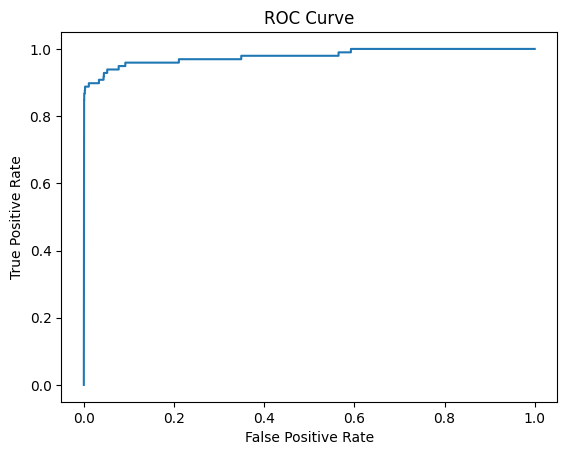

In [ ]:
fpr, tpr, _ = roc_curve(y_test, y_pred_prob_classical)

plt.figure()
plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

In [ ]:
n_qubits = 6
dev = qml.device("default.qubit", wires=n_qubits)
@qml.qnode(dev, interface="torch")
def quantum_circuit(inputs, weights):
    qml.AngleEmbedding(inputs, wires=range(n_qubits))
    qml.templates.StronglyEntanglingLayers(weights, wires=range(n_qubits))
    return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]
weight_shapes = {"weights": (3, n_qubits, 3)}
qlayer = TorchLayer(quantum_circuit, weight_shapes)
class HybridModel(nn.Module):
    def __init__(self):
        super(HybridModel, self).__init__()
        self.clayer_in = nn.Linear(4, n_qubits)
        self.qlayer = qlayer
        self.clayer_out = nn.Linear(n_qubits, 1)
    def forward(self, x):
        x = self.clayer_in(x)
        x = torch.tanh(x) * np.pi
        x = self.qlayer(x)
        x = self.clayer_out(x)
        return x
print("Training Hybrid Quantum Model...")
hybrid_model = HybridModel()
start_time = time.time()
train_pytorch_model(hybrid_model, train_loader_q, epochs=15, pos_weight=pos_weight)
hybrid_time = time.time() - start_time
print("\nHybrid Quantum Model Results:")
y_pred_prob_hybrid = evaluate_pytorch_model(hybrid_model, test_loader_q)
print(f"Training Time: {hybrid_time:.2f}s")

Training Hybrid Quantum Model...
Epoch 5/15, Loss: 1.1089
Epoch 10/15, Loss: 1.0315
Epoch 15/15, Loss: 1.0077

Hybrid Quantum Model Results:
              precision    recall  f1-score   support

         0.0       1.00      0.97      0.98     56864
         1.0       0.02      0.37      0.04        98

    accuracy                           0.97     56962
   macro avg       0.51      0.67      0.51     56962
weighted avg       1.00      0.97      0.98     56962

ROC-AUC: 0.8063
Training Time: 1164.53s


Text(0.5, 1.0, 'ROC Curve')

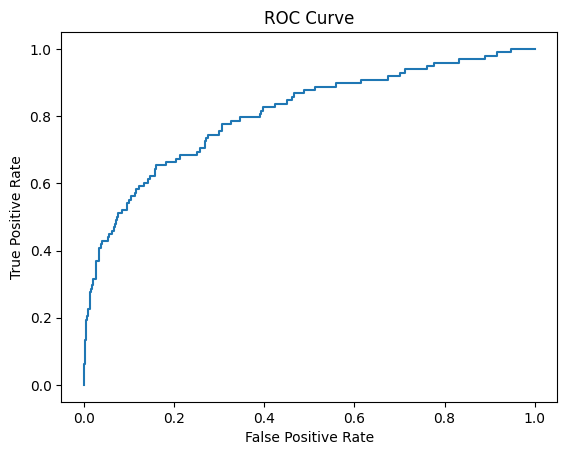

In [ ]:
fpr, tpr, _ = roc_curve(y_test, y_pred_prob_hybrid)
plt.figure()
plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

In [ ]:
print("Performance Summary:")
print(f"Classical Time: {classical_time:.2f}s, Hybrid Time: {hybrid_time:.2f}s")
print(f"Classical ROC-AUC: {roc_auc_score(y_test, y_pred_prob_classical):.4f}")
print(f"Hybrid ROC-AUC: {roc_auc_score(y_test, y_pred_prob_hybrid):.4f}")

Performance Summary:
Classical Time: 63.54s, Hybrid Time: 1164.53s
Classical ROC-AUC: 0.9786
Hybrid ROC-AUC: 0.8063
